In [1]:
#Step 1: Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.linear_model import LinearRegression

plt.rcParams["figure.figsize"] = (12,6)

In [2]:
#Step 2: Load Data
sales = pd.read_csv("../data/sales.csv")

sales["OrderDate"] = pd.to_datetime(sales["OrderDate"])

sales.head()

,OrderID,OrderDate,CustomerID,ProductID,Quantity,Discount,Sales,Profit
0,1,2025-12-25,958,80,2,20,4257.38,2497.72
1,2,2025-09-13,6007,485,1,5,7693.79,3299.73
2,3,2025-09-17,2654,418,5,20,11907.08,7248.85
3,4,2025-07-12,4593,217,4,10,23065.60,10516.44
4,5,2026-04-20,2969,230,3,5,2021.70,367.11


In [3]:
#Step 3: Create Monthly Sales Dataset
monthly_sales = (
    sales
    .groupby(
        sales["OrderDate"].dt.to_period("M")
    )["Sales"]
    .sum()
    .reset_index()
)

monthly_sales["OrderDate"] = (
    monthly_sales["OrderDate"]
    .dt.to_timestamp()
)

monthly_sales

,OrderDate,Sales
0,2024-07-01,17179658.01
1,2024-08-01,44880199.55
2,2024-09-01,46042190.46
3,2024-10-01,46990732.88
4,2024-11-01,46527189.79
5,2024-12-01,46687471.13
6,2025-01-01,46616382.29
7,2025-02-01,41027898.96
8,2025-03-01,44201856.52
9,2025-04-01,44109587.42


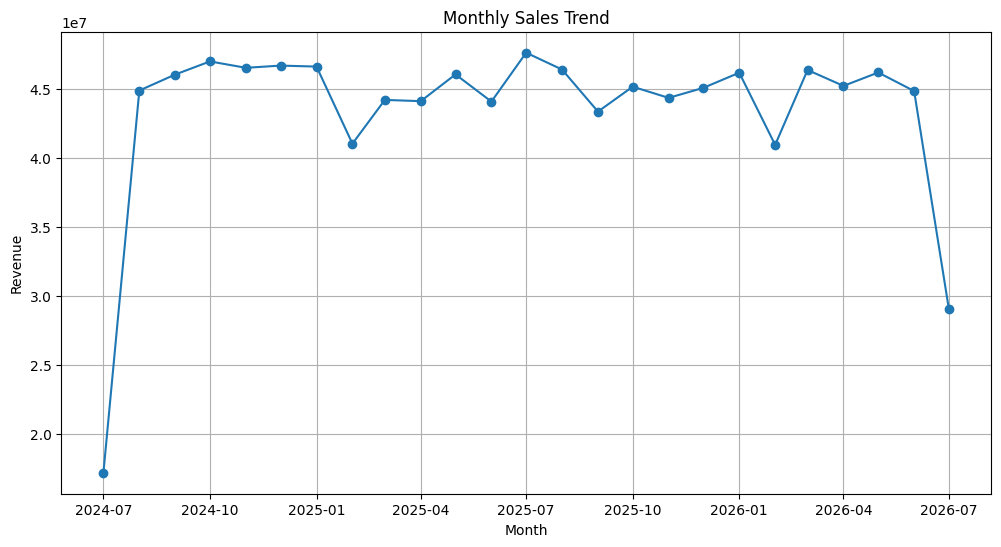

In [4]:
#Step 4: Plot Historical Sales
plt.plot(
    monthly_sales["OrderDate"],
    monthly_sales["Sales"],
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(True)
plt.show()

In [6]:
#Step 5: Prepare Data for Forecasting
#Machine learning models require numerical inputs.

monthly_sales["MonthIndex"] = range(
    len(monthly_sales)
)

monthly_sales

,OrderDate,Sales,MonthIndex
0,2024-07-01,17179658.01,0
1,2024-08-01,44880199.55,1
2,2024-09-01,46042190.46,2
3,2024-10-01,46990732.88,3
4,2024-11-01,46527189.79,4
5,2024-12-01,46687471.13,5
6,2025-01-01,46616382.29,6
7,2025-02-01,41027898.96,7
8,2025-03-01,44201856.52,8
9,2025-04-01,44109587.42,9


In [7]:
#Step 6: Create Features and Target
X = monthly_sales[["MonthIndex"]]
y = monthly_sales["Sales"]

In [8]:
#Step 7: Train the Model
model = LinearRegression()

model.fit(X, y)

LinearRegression()

In [9]:
#Step 8: Predict Historical Values
monthly_sales["PredictedSales"] = model.predict(X)

monthly_sales.head()

,OrderDate,Sales,MonthIndex,PredictedSales
0,2024-07-01,17179658.01,0,4.244354e+07
1,2024-08-01,44880199.55,1,4.252364e+07
2,2024-09-01,46042190.46,2,4.260374e+07
3,2024-10-01,46990732.88,3,4.268384e+07
4,2024-11-01,46527189.79,4,4.276394e+07


In [10]:
#Step 9: Forecast Next 6 Months
future_months = pd.DataFrame({

    "MonthIndex": range(
        len(monthly_sales),
        len(monthly_sales) + 6
    )

})

future_months["ForecastSales"] = model.predict(
    future_months
)

future_months

,MonthIndex,ForecastSales
0,25,4.444610e+07
1,26,4.452620e+07
2,27,4.460630e+07
3,28,4.468640e+07
4,29,4.476651e+07
5,30,4.484661e+07


In [11]:
#Step 10: Create Future Dates
last_date = monthly_sales["OrderDate"].max()

future_dates = pd.date_range(

    start=last_date + pd.DateOffset(months=1),

    periods=6,

    freq="MS"

)

future_months["OrderDate"] = future_dates

future_months

,MonthIndex,ForecastSales,OrderDate
0,25,4.444610e+07,2026-08-01
1,26,4.452620e+07,2026-09-01
2,27,4.460630e+07,2026-10-01
3,28,4.468640e+07,2026-11-01
4,29,4.476651e+07,2026-12-01
5,30,4.484661e+07,2027-01-01


In [12]:
#Step 11: Combine Historical & Forecast
forecast_df = future_months[
    [
        "OrderDate",
        "ForecastSales"
    ]
]

forecast_df

,OrderDate,ForecastSales
0,2026-08-01,4.444610e+07
1,2026-09-01,4.452620e+07
2,2026-10-01,4.460630e+07
3,2026-11-01,4.468640e+07
4,2026-12-01,4.476651e+07
5,2027-01-01,4.484661e+07


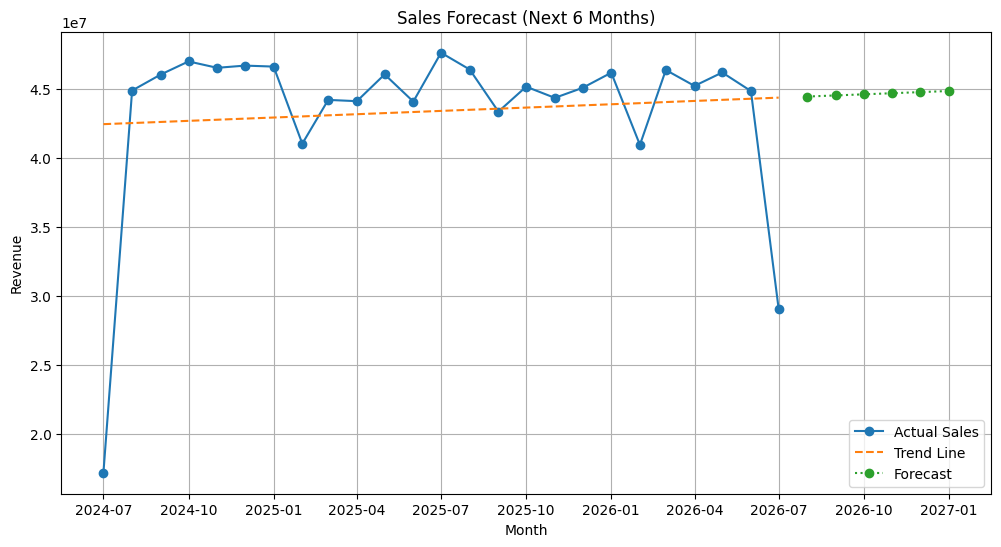

In [13]:
#Step 12: Visualize Forecast
plt.plot(
    monthly_sales["OrderDate"],
    monthly_sales["Sales"],
    marker="o",
    label="Actual Sales"
)

plt.plot(
    monthly_sales["OrderDate"],
    monthly_sales["PredictedSales"],
    linestyle="--",
    label="Trend Line"
)

plt.plot(
    forecast_df["OrderDate"],
    forecast_df["ForecastSales"],
    marker="o",
    linestyle=":",
    label="Forecast"
)

plt.title("Sales Forecast (Next 6 Months)")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.legend()
plt.grid(True)
plt.show()

In [14]:
#Step 13: Model Performance (R² Score)
r2 = model.score(X, y)

print(f"R² Score: {r2:.3f}")

R² Score: 0.008


In [15]:
#Step 14: Export Forecast
forecast_df.to_csv(
    "../reports/sales_forecast.csv",
    index=False
)

## Sales Forecast - Business Insights

1. Historical monthly sales remain relatively stable with moderate fluctuations.

2. The linear trend model provides an estimate of future monthly sales based on historical performance.

3. Forecast results can support inventory planning and purchasing decisions.

4. Significant deviations from the forecast in future periods may indicate changes in customer demand or market conditions.

5. Forecasts should be reviewed periodically as new sales data becomes available.